# Option Pricing Engine Demo

This notebook demonstrates the pricing of European call and put options using:

- Black-Scholes analytical model
- Monte Carlo simulation
- Greeks computation
- Implied volatility estimation

The objective is to validate the numerical methods and compare results across approaches.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from black_scholes import call_price, put_price
from monte_carlo import monte_carlo_call, monte_carlo_put
from greeks import delta_call, gamma, vega
from implied_vol import implied_vol

## market parameters

In [2]:
S0 = 100      # spot price
K = 105       # strike
T = 1         # maturity in years
r = 0.05      # risk-free rate
sigma = 0.20  # annual volatility

print(f"Spot: {S0}")
print(f"Strike: {K}")
print(f"Maturity: {T} year")
print(f"Rate: {r}")
print(f"Volatility: {sigma}")

Spot: 100
Strike: 105
Maturity: 1 year
Rate: 0.05
Volatility: 0.2


## Black-Scholes Analytical Prices

In [3]:
call_bs = call_price(S0, K, T, r, sigma)
put_bs = put_price(S0, K, T, r, sigma)

print(f"Call Price (BS): {call_bs:.4f}")
print(f"Put Price (BS): {put_bs:.4f}")

Call Price (BS): 8.0214
Put Price (BS): 7.9004


## Monte Carlo Validation
Compare Monte Carlo prices against the analytical Black-Scholes benchmark.

Call Price (MC): 7.9042
Put Price (MC): 7.8791
Call Error: 0.1172
Put Error: 0.0214


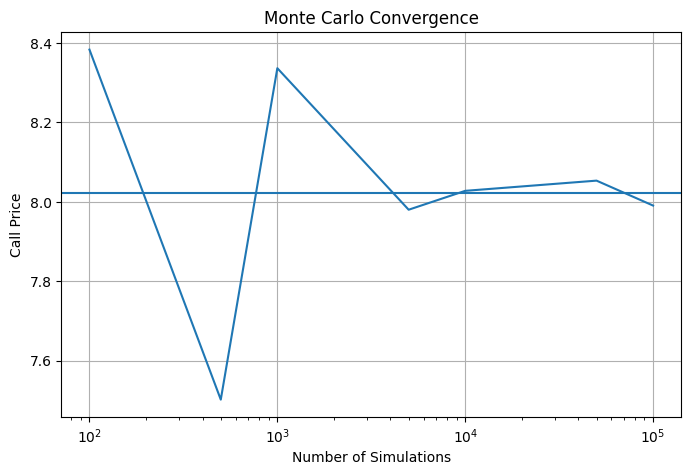

In [6]:
call_mc = monte_carlo_call(S0, K, T, r, sigma)
put_mc = monte_carlo_put(S0, K, T, r, sigma)

print(f"Call Price (MC): {call_mc:.4f}")
print(f"Put Price (MC): {put_mc:.4f}")

print(f"Call Error: {abs(call_bs - call_mc):.4f}")
print(f"Put Error: {abs(put_bs - put_mc):.4f}")

simulations = [100, 500, 1000, 5000, 10000, 50000, 100000]
prices = []

for n in simulations:
    price = monte_carlo_call(S0, K, T, r, sigma, n_sim=n)
    prices.append(price)

plt.figure(figsize=(8,5))
plt.plot(simulations, prices)
plt.axhline(call_bs)
plt.xscale("log")
plt.xlabel("Number of Simulations")
plt.ylabel("Call Price")
plt.title("Monte Carlo Convergence")
plt.grid(True)
plt.show()

## Greek sensivity

In [7]:
spots = np.linspace(80, 120, 100)

deltas = [delta_call(S, K, T, r, sigma) for S in spots]
gammas = [gamma(S, K, T, r, sigma) for S in spots]
vegas = [vega(S, K, T, r, sigma) for S in spots]

## Delta plot

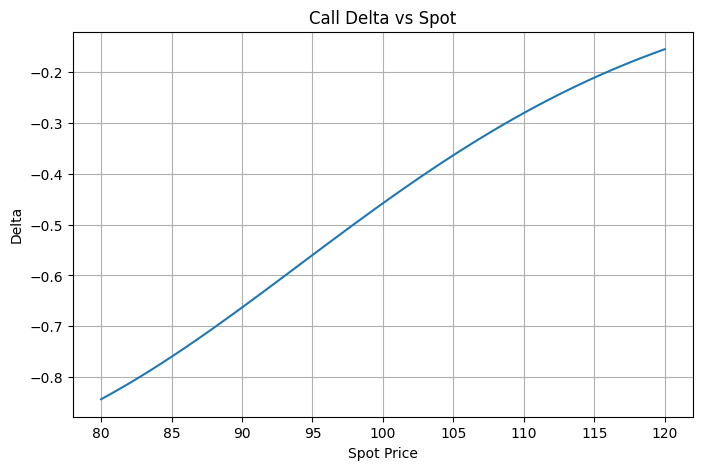

In [8]:
plt.figure(figsize=(8,5))
plt.plot(spots, deltas)
plt.xlabel("Spot Price")
plt.ylabel("Delta")
plt.title("Call Delta vs Spot")
plt.grid(True)
plt.show()

## Gamma plot

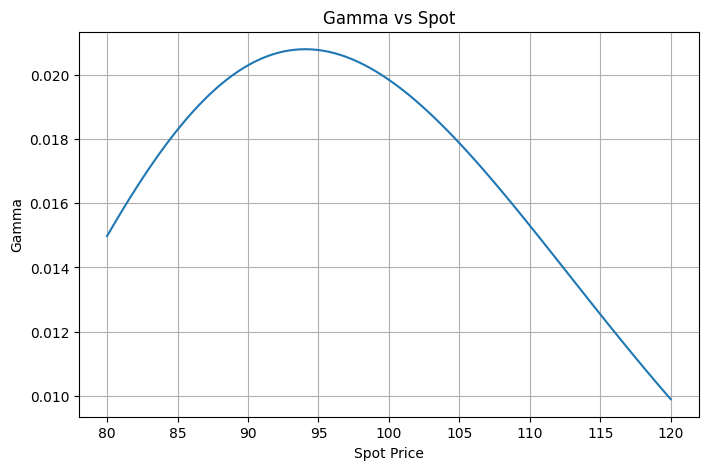

In [9]:
plt.figure(figsize=(8,5))
plt.plot(spots, gammas)
plt.xlabel("Spot Price")
plt.ylabel("Gamma")
plt.title("Gamma vs Spot")
plt.grid(True)
plt.show()

## Vega plot

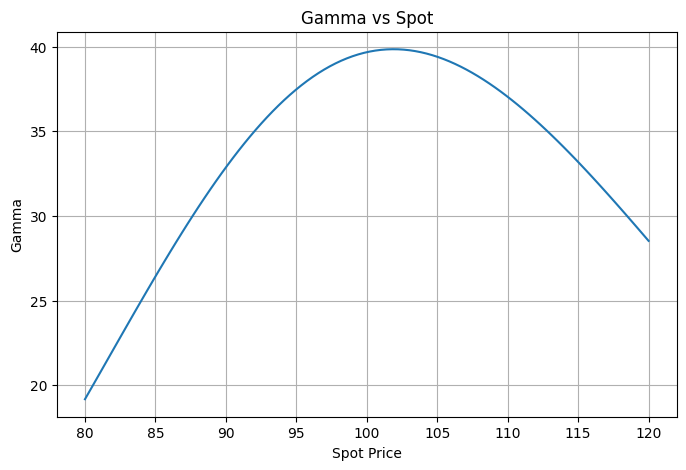

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(spots, vegas)
plt.xlabel("Spot Price")
plt.ylabel("Vega")
plt.title("Vega vs Spot")
plt.grid(True)
plt.show()

## Price vs volatility 

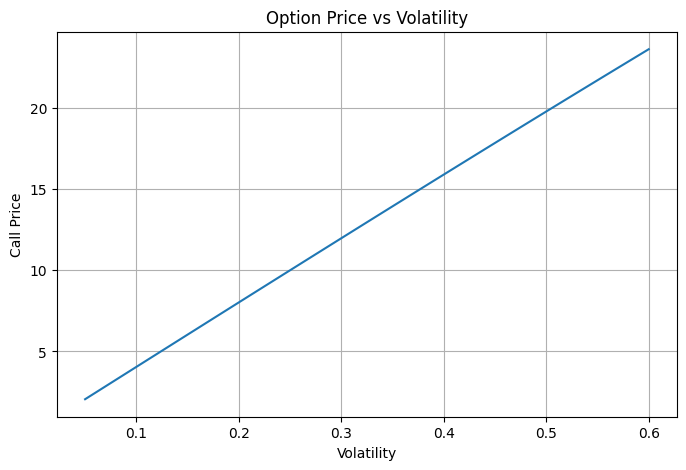

In [11]:
vols = np.linspace(0.05, 0.6, 100)
prices = [call_price(S0, K, T, r, vol) for vol in vols]

plt.figure(figsize=(8,5))
plt.plot(vols, prices)
plt.xlabel("Volatility")
plt.ylabel("Call Price")
plt.title("Option Price vs Volatility")
plt.grid(True)
plt.show()

## Implied Volatility Recovery
Recover the volatility from a synthetic market option price.

In [12]:
market_price = call_bs

iv = implied_vol(market_price, S0, K, T, r)

print(f"Original sigma: {sigma}")
print(f"Recovered IV: {iv:.4f}")

Original sigma: 0.2
Recovered IV: 0.2000
